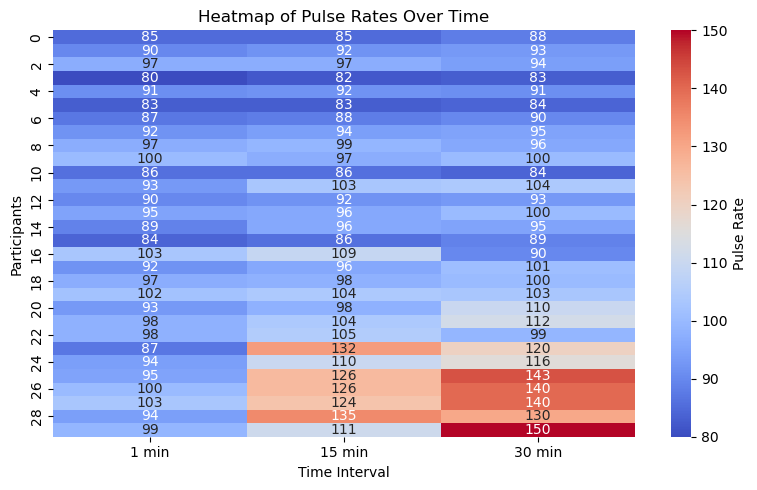

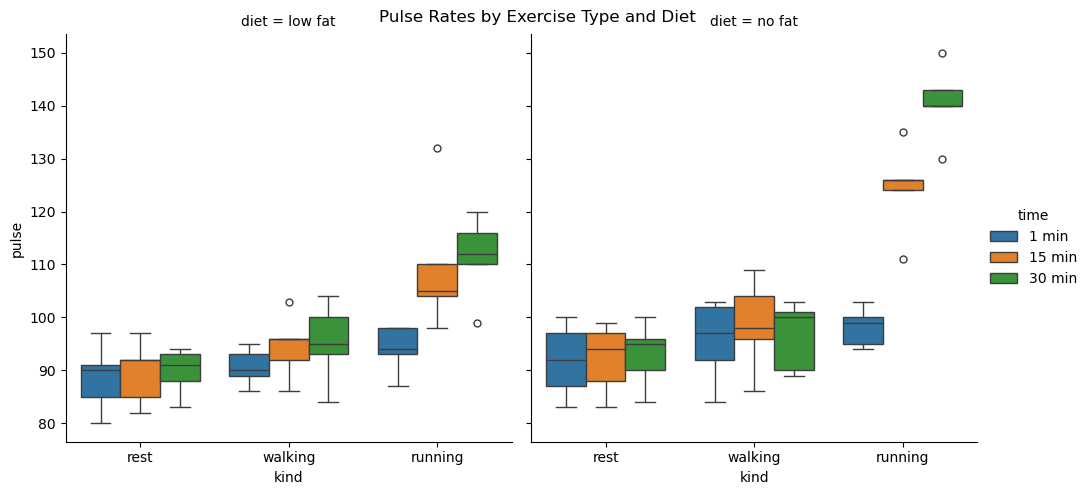

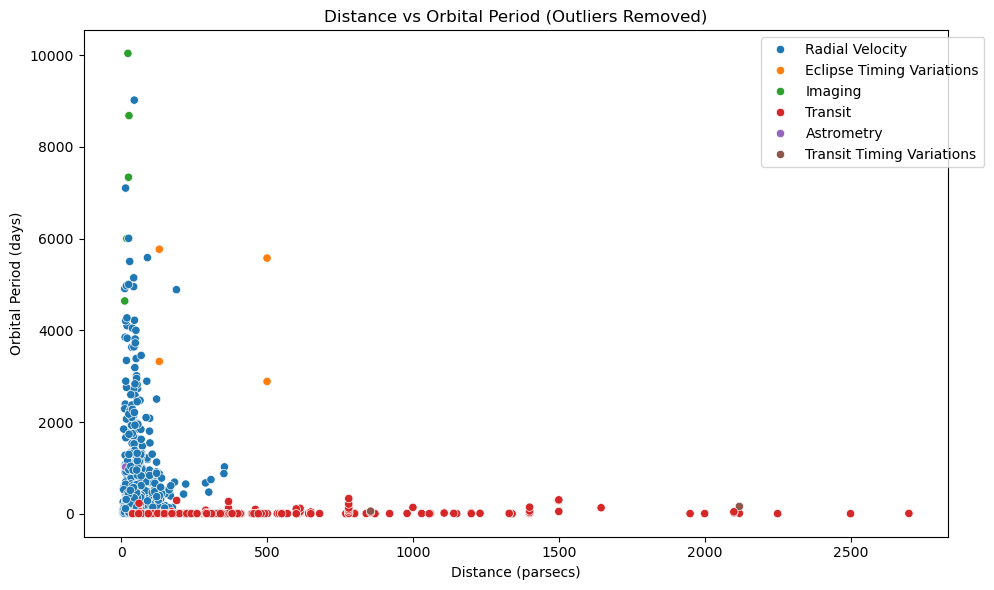

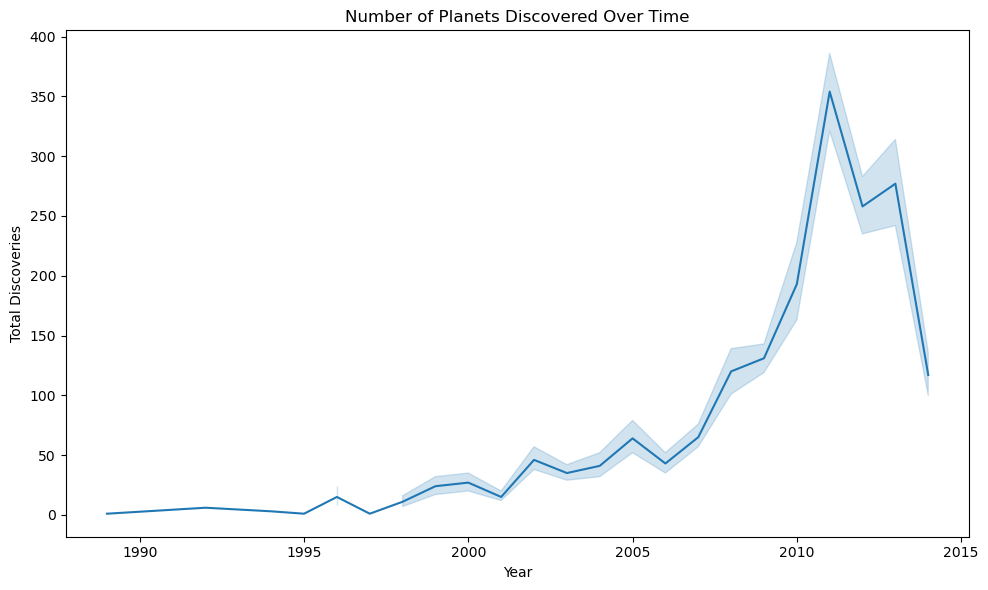

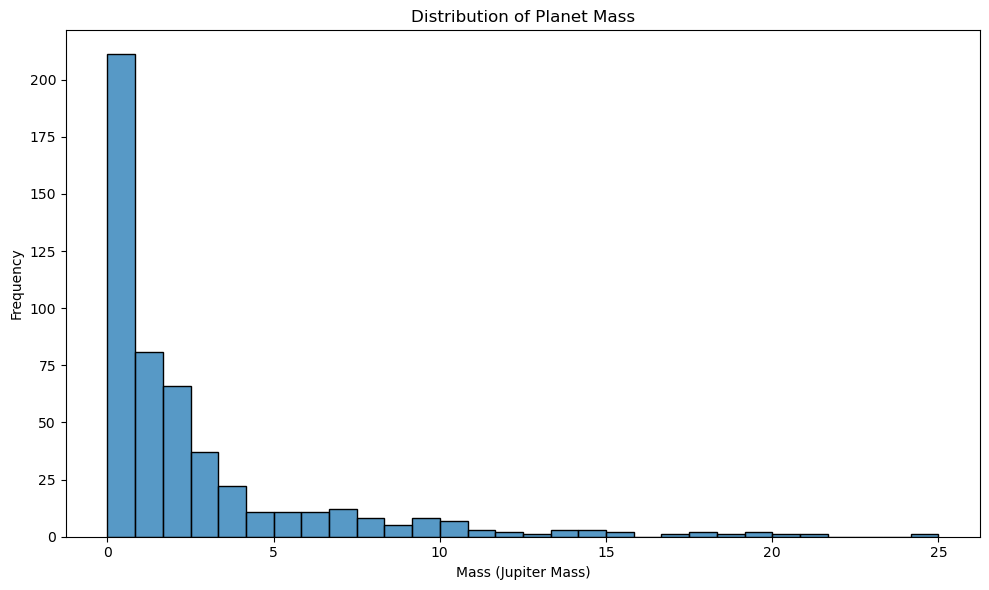

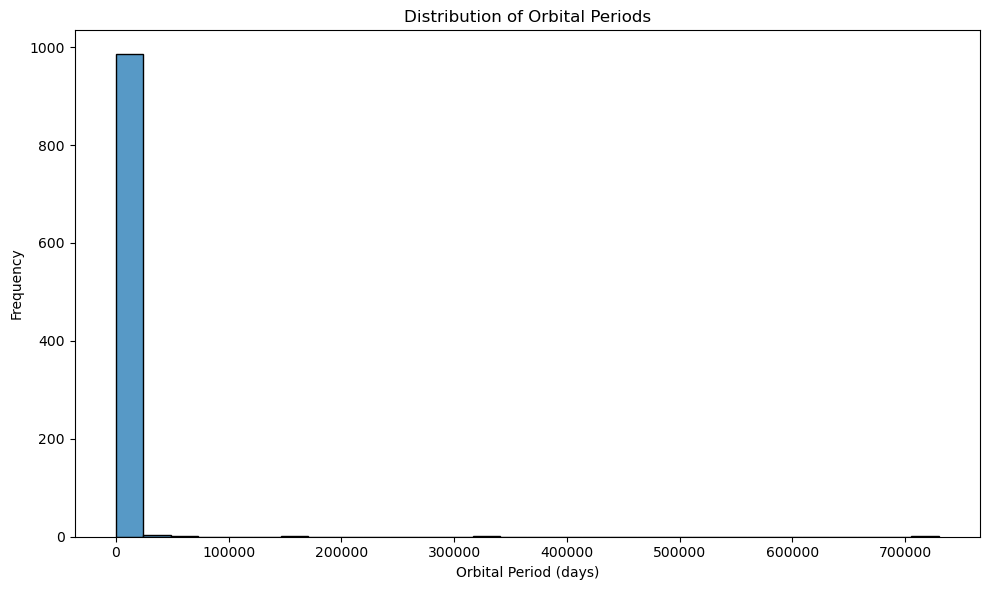

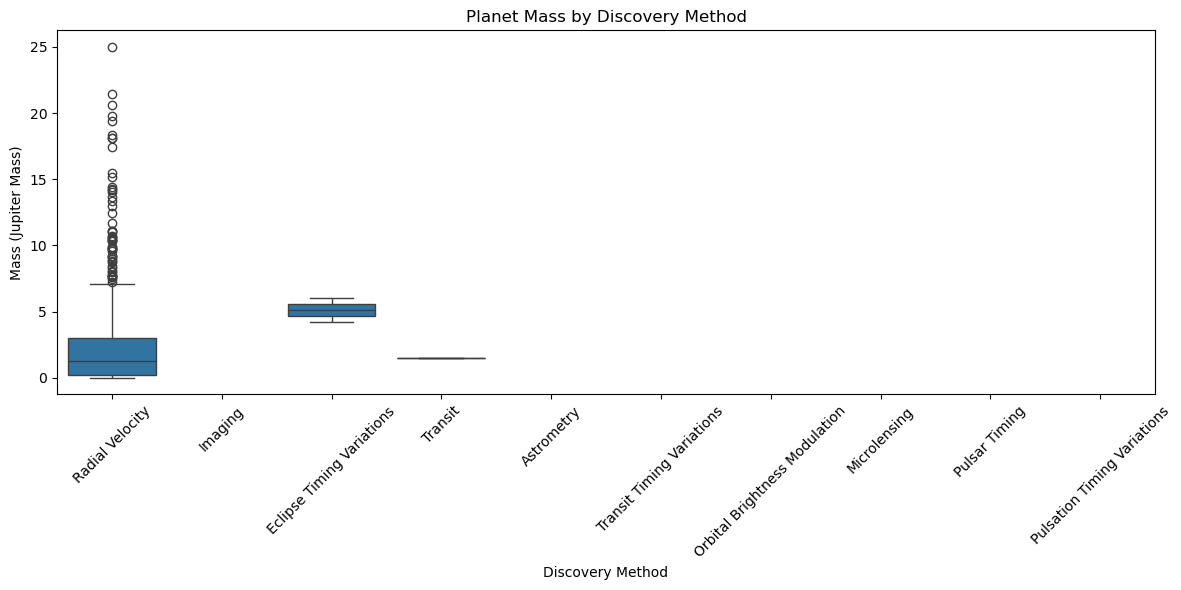

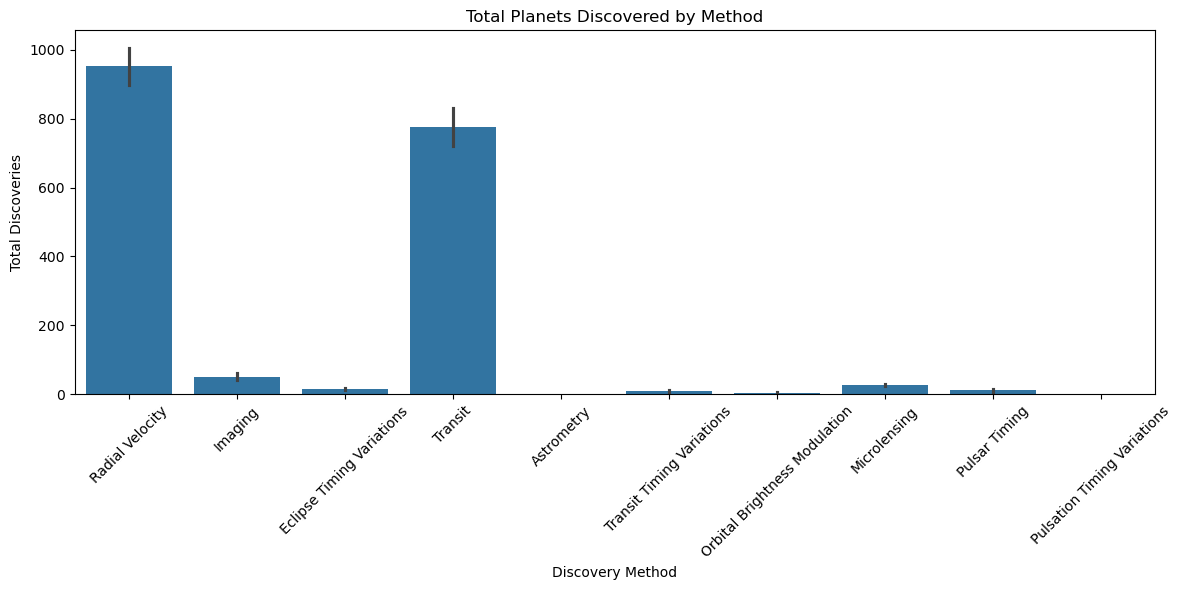

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Exercise_Data.csv')


#=============================================================================================
#Pulse Data Heatmap Part 1

pulse_data = df[['1 min', '15 min', '30 min']] #numerical data only

# Create the heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    pulse_data,
    annot=True,          # shows numbers inside cells
    fmt=".0f",           # no decimals
    cmap="coolwarm",     # color style
    cbar_kws={'label': 'Pulse Rate'}
)

# Labels and title
plt.title("Heatmap of Pulse Rates Over Time")
plt.xlabel("Time Interval")
plt.ylabel("Participants")

plt.tight_layout()
plt.show()

#=============================================================================================

#Categorical Plot Part 1

df_long = df.melt(#makes into long data so it can go into catplot
    id_vars=['diet', 'kind'],
    value_vars=['1 min', '15 min', '30 min'],
    var_name='time',
    value_name='pulse'
)

sns.catplot(
    data=df_long,
    x='kind',
    y='pulse',
    hue='time',
    col='diet',
    kind='box',
    height=5
)

plt.suptitle("Pulse Rates by Exercise Type and Diet")
plt.show()

#=============================================================================================

# Part 2

df = sns.load_dataset("planets")

# -----------------------------------
# Relational Plots

# 1. Scatter Plot
#get rid of outliers
q_low = df[['distance', 'orbital_period']].quantile(0.01)
q_high = df[['distance', 'orbital_period']].quantile(0.99)

df_filtered = df[
    (df['distance'] >= q_low['distance']) & (df['distance'] <= q_high['distance']) &
    (df['orbital_period'] >= q_low['orbital_period']) & (df['orbital_period'] <= q_high['orbital_period'])
]

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_filtered, x="distance", y="orbital_period", hue="method")

plt.title("Distance vs Orbital Period (Outliers Removed)")
plt.xlabel("Distance (parsecs)")
plt.ylabel("Orbital Period (days)")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

# 2. Line Plot
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="year", y="number", estimator="sum")
plt.title("Number of Planets Discovered Over Time")
plt.xlabel("Year")
plt.ylabel("Total Discoveries")
plt.tight_layout()
plt.show()


# -----------------------------------
# Distribution Plots

# 3. Histogram 
plt.figure(figsize=(10,6))
sns.histplot(df["mass"].dropna(), bins=30)

#customize
plt.title("Distribution of Planet Mass")
plt.xlabel("Mass (Jupiter Mass)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Histogram (orbital period)
plt.figure(figsize=(10,6))
sns.histplot(df["orbital_period"].dropna(), bins=30)
#customize
plt.title("Distribution of Orbital Periods")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# -----------------------------------
# Categorical Plots

# 5. Box Plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="method", y="mass")
#customize
plt.title("Planet Mass by Discovery Method")
plt.xlabel("Discovery Method")
plt.ylabel("Mass (Jupiter Mass)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Bar Plot
plt.figure(figsize=(12,6))
sns.barplot(data=df, x="method", y="number", estimator=sum)
#customize
plt.title("Total Planets Discovered by Method")
plt.xlabel("Discovery Method")
plt.ylabel("Total Discoveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()